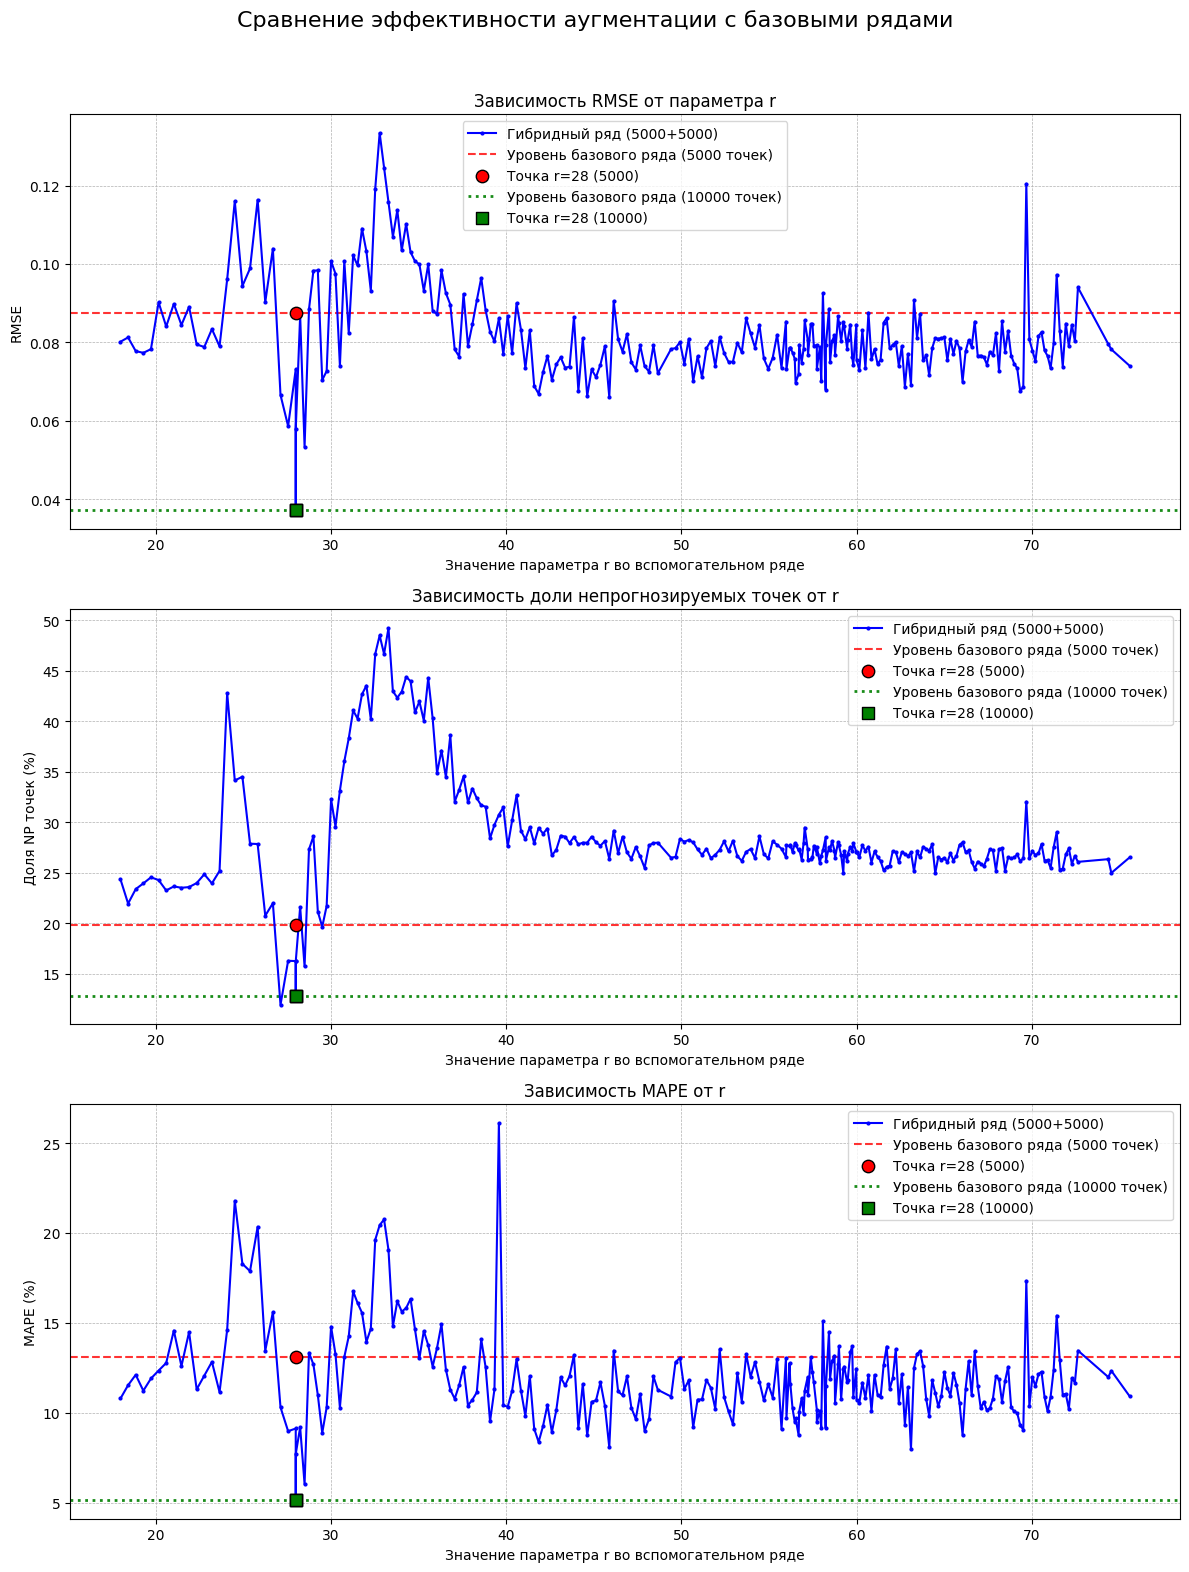

In [2]:
import matplotlib.pyplot as plt
import pandas as pd

# --- Подготовка данных (без изменений) ---

# Чтение данных из файла
df = pd.read_csv('deviation_results.txt', header=None)
df[0] = df[0] + 28 # Смещаем r, чтобы 0 стал 28
# Переводим доли в проценты для наглядности
df[4] = df[4] * 100 # NP в проценты
df[5] = df[5] * 100 # MAPE в проценты

# Находим строку для контрольного случая 1: базовый ряд 5000 точек
special_row_5k = df[df[6] == 5000]

# Готовим основной набор данных (гибридные ряды)
df_without_special = df[df[6] != 5000]
df_sorted = df_without_special.sort_values(by=0)

# Находим строку для контрольного случая 2: базовый ряд 10000 точек (это случай, где r=28)
baseline_10k_row = df_sorted[df_sorted[0] == 28]

# --- Построение графиков с исправлениями ---

fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(12, 16))
fig.suptitle('Сравнение эффективности аугментации с базовыми рядами', fontsize=16)

# === 1. График RMSE ===
ax1.plot(df_sorted[0], df_sorted[3], 'b-', marker='.', markersize=4, label='Гибридный ряд (5000+5000)', zorder=10)

# Контрольный уровень для 5000 точек
if not special_row_5k.empty:
    # Горизонтальная линия
    ax1.axhline(y=special_row_5k[3].values[0], color='red', linestyle='--', alpha=0.8, linewidth=1.5, label='Уровень базового ряда (5000 точек)')
    # Подсветка самой точки КРАСНЫМ цветом
    ax1.scatter(special_row_5k[0], special_row_5k[3], color='red', s=80, edgecolors='black', zorder=15, label='Точка r=28 (5000)')

# Контрольный уровень для 10000 точек
if not baseline_10k_row.empty:
    # Горизонтальная линия
    ax1.axhline(y=baseline_10k_row[3].values[0], color='green', linestyle=':', alpha=0.9, linewidth=2, label='Уровень базового ряда (10000 точек)')
    # Подсветка самой точки ЗЕЛЕНЫМ цветом
    ax1.scatter(baseline_10k_row[0], baseline_10k_row[3], color='green', marker='s', s=80, edgecolors='black', zorder=15, label='Точка r=28 (10000)')

ax1.set_xlabel('Значение параметра r во вспомогательном ряде')
ax1.set_ylabel('RMSE')
ax1.set_title('Зависимость RMSE от параметра r')
ax1.grid(True, which='both', linestyle='--', linewidth=0.5)
ax1.legend()

# === 2. График NP (доля непрогнозируемых точек) ===
ax2.plot(df_sorted[0], df_sorted[4], 'b-', marker='.', markersize=4, label='Гибридный ряд (5000+5000)', zorder=10)

# Контрольный уровень для 5000 точек
if not special_row_5k.empty:
    ax2.axhline(y=special_row_5k[4].values[0], color='red', linestyle='--', alpha=0.8, linewidth=1.5, label='Уровень базового ряда (5000 точек)')
    ax2.scatter(special_row_5k[0], special_row_5k[4], color='red', s=80, edgecolors='black', zorder=15, label='Точка r=28 (5000)')

# Контрольный уровень для 10000 точек
if not baseline_10k_row.empty:
    ax2.axhline(y=baseline_10k_row[4].values[0], color='green', linestyle=':', alpha=0.9, linewidth=2, label='Уровень базового ряда (10000 точек)')
    ax2.scatter(baseline_10k_row[0], baseline_10k_row[4], color='green', marker='s', s=80, edgecolors='black', zorder=15, label='Точка r=28 (10000)')

ax2.set_xlabel('Значение параметра r во вспомогательном ряде')
ax2.set_ylabel('Доля NP точек (%)')
ax2.set_title('Зависимость доли непрогнозируемых точек от r')
ax2.grid(True, which='both', linestyle='--', linewidth=0.5)
ax2.legend()

# === 3. График MAPE ===
ax3.plot(df_sorted[0], df_sorted[5], 'b-', marker='.', markersize=4, label='Гибридный ряд (5000+5000)', zorder=10)

# Контрольный уровень для 5000 точек
if not special_row_5k.empty:
    ax3.axhline(y=special_row_5k[5].values[0], color='red', linestyle='--', alpha=0.8, linewidth=1.5, label='Уровень базового ряда (5000 точек)')
    ax3.scatter(special_row_5k[0], special_row_5k[5], color='red', s=80, edgecolors='black', zorder=15, label='Точка r=28 (5000)')

# Контрольный уровень для 10000 точек
if not baseline_10k_row.empty:
    ax3.axhline(y=baseline_10k_row[5].values[0], color='green', linestyle=':', alpha=0.9, linewidth=2, label='Уровень базового ряда (10000 точек)')
    ax3.scatter(baseline_10k_row[0], baseline_10k_row[5], color='green', marker='s', s=80, edgecolors='black', zorder=15, label='Точка r=28 (10000)')

ax3.set_xlabel('Значение параметра r во вспомогательном ряде')
ax3.set_ylabel('MAPE (%)')
ax3.set_title('Зависимость MAPE от r')
ax3.grid(True, which='both', linestyle='--', linewidth=0.5)
ax3.legend()

plt.tight_layout(rect=[0, 0, 1, 0.96]) # Оставляем место для общего заголовка
plt.savefig('Разные_r_сравнение_с_точками.png', dpi=300)
plt.show()